## **Name:** Sameer Gupta
## **Roll No:** 252010036

### Question 1: IRIS Dataset

Classify the dataset IRIS using Decision tree. For dataset 'IRIS' consider correlation matrix for feature selection and compare between 4 models(all feature, only petals, only sepals, and best 3 features from correlation matrix). draw a bar chart of this summary. (use entropy as the criteria for classification).

**General Requirements:**
a) perform all the initial EDA analysis
b) Plot pair plot for IRIS. 
c) Remove Outlier in all the cases

=== IRIS DATASET ===

--- Initial EDA: Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

--- Initial EDA: Describe ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.

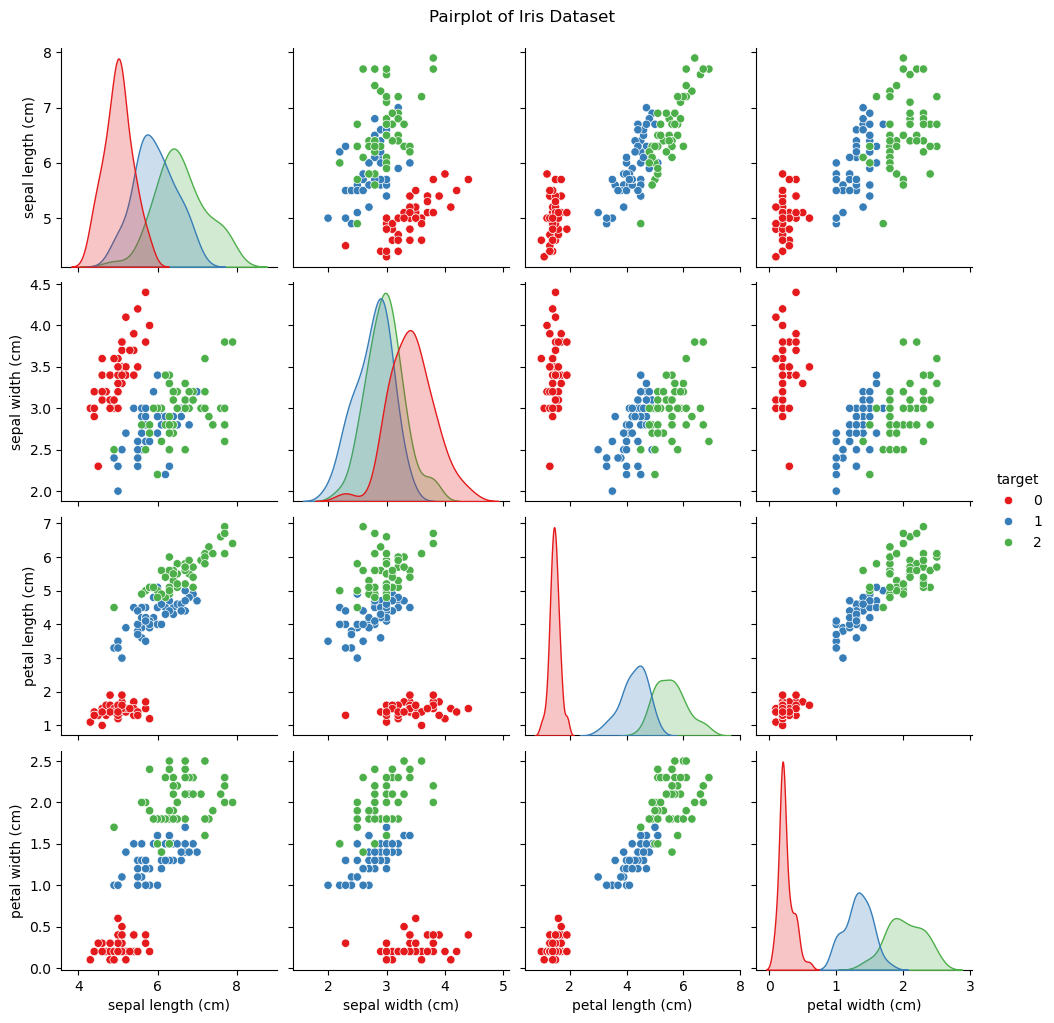


Original Iris shape: (150, 5), After Outlier Removal: (142, 5)

Correlation Matrix:
                    sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.226237           0.870430   
sepal width (cm)           -0.226237          1.000000          -0.508601   
petal length (cm)           0.870430         -0.508601           1.000000   
petal width (cm)            0.815823         -0.430027           0.961136   
target                      0.779696         -0.491746           0.946469   

                   petal width (cm)    target  
sepal length (cm)          0.815823  0.779696  
sepal width (cm)          -0.430027 -0.491746  
petal length (cm)          0.961136  0.946469  
petal width (cm)           1.000000  0.953940  
target                     0.953940  1.000000  


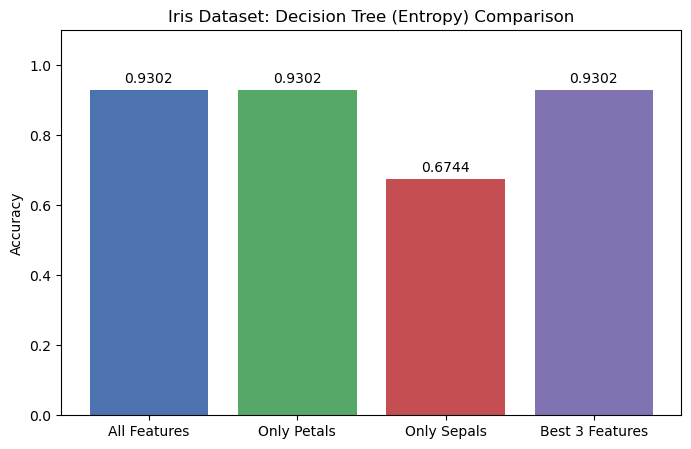

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_wine, load_digits
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Common function to remove outliers using Isolation Forest 
# (Robust for high dimensional and varied datasets without losing too much data)
def remove_outliers(df, target_col):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    iso = IsolationForest(contamination=0.05, random_state=42)
    yhat = iso.fit_predict(X)
    mask = yhat != -1
    return df[mask].reset_index(drop=True)

print("=== IRIS DATASET ===")
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target

# a) Initial EDA analysis
print("\n--- Initial EDA: Info ---")
print(df_iris.info())
print("\n--- Initial EDA: Describe ---")
print(df_iris.describe())

# b) Plot pair plot for IRIS
sns.pairplot(df_iris, hue='target', palette='Set1')
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()

# c) Remove Outliers
df_iris_clean = remove_outliers(df_iris, 'target')
print(f"\nOriginal Iris shape: {df_iris.shape}, After Outlier Removal: {df_iris_clean.shape}")

# Feature Selection using Correlation Matrix
corr_matrix = df_iris_clean.corr()
print("\nCorrelation Matrix:\n", corr_matrix)

# Best 3 features based on absolute correlation with target
target_corr = corr_matrix['target'].drop('target').abs().sort_values(ascending=False)
best_3_features = target_corr.head(3).index.tolist()

X_iris = df_iris_clean.drop(columns=['target'])
y_iris = df_iris_clean['target']

# Define models
all_features = X_iris.columns.tolist()
petal_features = [col for col in all_features if 'petal' in col]
sepal_features = [col for col in all_features if 'sepal' in col]

feature_sets = {
    'All Features': all_features,
    'Only Petals': petal_features,
    'Only Sepals': sepal_features,
    'Best 3 Features': best_3_features
}

accuracies_iris = {}
for name, features in feature_sets.items():
    X_subset = X_iris[features]
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y_iris, test_size=0.3, random_state=42)
    # Entropy as criteria
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)
    accuracies_iris[name] = accuracy_score(y_test, clf.predict(X_test))

# Draw a bar chart of this summary
plt.figure(figsize=(8, 5))
bars = plt.bar(accuracies_iris.keys(), accuracies_iris.values(), color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.ylabel('Accuracy')
plt.title('Iris Dataset: Decision Tree (Entropy) Comparison')
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 4), ha='center')
plt.show()

### Question 2: WINE Dataset

For dataset 'Wines' use correlation matrix for feature selection and compare the various models. 
draw a bar chart of this summary. (use gini index as the criteria for classification)

**General Requirements:**
a) perform all the initial EDA analysis
c) Remove Outlier in all the cases

=== WINE DATASET ===

--- Initial EDA: Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline         

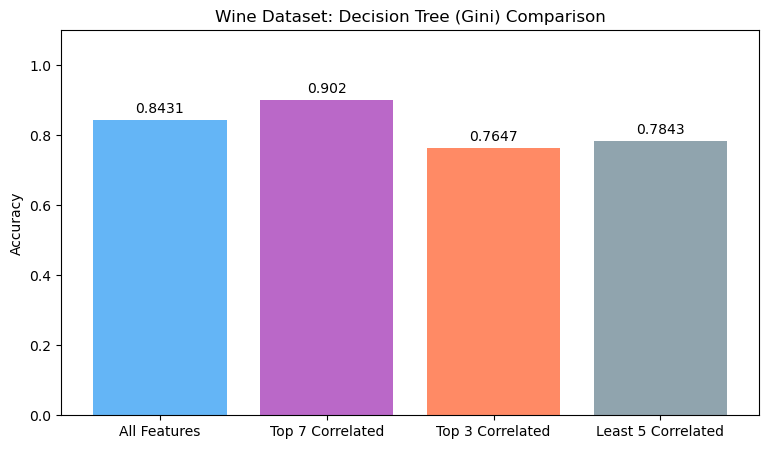

In [2]:
print("=== WINE DATASET ===")
wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target

# a) Initial EDA analysis
print("\n--- Initial EDA: Info ---")
print(df_wine.info())
print("\n--- Initial EDA: Describe ---")
print(df_wine.describe())

# c) Remove Outliers
df_wine_clean = remove_outliers(df_wine, 'target')
print(f"\nOriginal Wine shape: {df_wine.shape}, After Outlier Removal: {df_wine_clean.shape}")

# Feature Selection using Correlation Matrix
corr_matrix_wine = df_wine_clean.corr()
target_corr_wine = corr_matrix_wine['target'].drop('target').abs().sort_values(ascending=False)

X_wine = df_wine_clean.drop(columns=['target'])
y_wine = df_wine_clean['target']

# Comparing various models based on feature selection
wine_feature_sets = {
    'All Features': X_wine.columns.tolist(),
    'Top 7 Correlated': target_corr_wine.head(7).index.tolist(),
    'Top 3 Correlated': target_corr_wine.head(3).index.tolist(),
    'Least 5 Correlated': target_corr_wine.tail(5).index.tolist()
}

accuracies_wine = {}
for name, features in wine_feature_sets.items():
    X_subset = X_wine[features]
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y_wine, test_size=0.3, random_state=42)
    # Gini index as criteria
    clf = DecisionTreeClassifier(criterion='gini', random_state=42)
    clf.fit(X_train, y_train)
    accuracies_wine[name] = accuracy_score(y_test, clf.predict(X_test))

# Draw a bar chart of this summary
plt.figure(figsize=(9, 5))
bars = plt.bar(accuracies_wine.keys(), accuracies_wine.values(), color=['#64B5F6', '#BA68C8', '#FF8A65', '#90A4AE'])
plt.ylabel('Accuracy')
plt.title('Wine Dataset: Decision Tree (Gini) Comparison')
plt.ylim(0, 1.1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 4), ha='center')
plt.show()

### Question 3: DIGIT Dataset

For dataset 'DIGIT' use PCA or SVD as dimensionality reduction techniques and compare 7 models 
(all feature, 30 components of PCA, 20 components of PCA, 15 components of PCA, 10 components of PCA, 5 components of PCA, 2 components of PCA). 
Summarise the results as a plot. (Use entropy as the criteria for classification).

**General Requirements:**
a) perform all the initial EDA analysis
c) Remove Outlier in all the cases

=== DIGIT DATASET ===

--- Initial EDA: Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1797 non-null   float64
 1   1       1797 non-null   float64
 2   2       1797 non-null   float64
 3   3       1797 non-null   float64
 4   4       1797 non-null   float64
 5   5       1797 non-null   float64
 6   6       1797 non-null   float64
 7   7       1797 non-null   float64
 8   8       1797 non-null   float64
 9   9       1797 non-null   float64
 10  10      1797 non-null   float64
 11  11      1797 non-null   float64
 12  12      1797 non-null   float64
 13  13      1797 non-null   float64
 14  14      1797 non-null   float64
 15  15      1797 non-null   float64
 16  16      1797 non-null   float64
 17  17      1797 non-null   float64
 18  18      1797 non-null   float64
 19  19      1797 non-null   float64
 20  20      1797 non-null   f

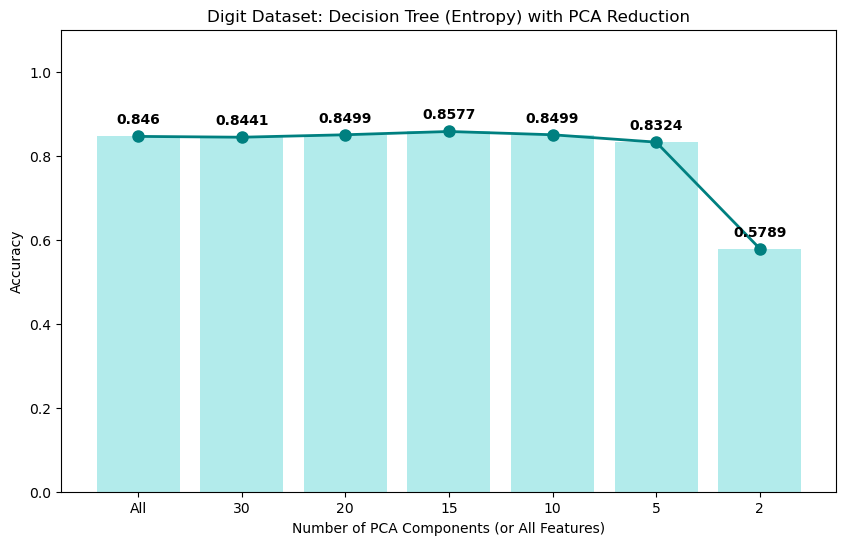

In [3]:
print("=== DIGIT DATASET ===")
digits = load_digits()
df_digits = pd.DataFrame(digits.data)
df_digits['target'] = digits.target

# a) Initial EDA analysis
print("\n--- Initial EDA: Info ---")
print(df_digits.info())
print("\n--- Initial EDA: Data snippet ---")
print(df_digits.head())

# c) Remove Outliers
df_digits_clean = remove_outliers(df_digits, 'target')
print(f"\nOriginal Digits shape: {df_digits.shape}, After Outlier Removal: {df_digits_clean.shape}")

X_dig = df_digits_clean.drop(columns=['target'])
y_dig = df_digits_clean['target']

X_train_dig, X_test_dig, y_train_dig, y_test_dig = train_test_split(X_dig, y_dig, test_size=0.3, random_state=42)

# Compare 7 models based on PCA components
pca_components = ['All', 30, 20, 15, 10, 5, 2]
accuracies_dig = {}

for comp in pca_components:
    if comp == 'All':
        X_tr, X_te = X_train_dig, X_test_dig
    else:
        pca = PCA(n_components=comp, random_state=42)
        X_tr = pca.fit_transform(X_train_dig)
        X_te = pca.transform(X_test_dig)
        
    # Entropy as criteria
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_tr, y_train_dig)
    y_pred = clf.predict(X_te)
    accuracies_dig[str(comp)] = accuracy_score(y_test_dig, y_pred)

# Summarise the results as a plot
plt.figure(figsize=(10, 6))
keys = list(accuracies_dig.keys())
values = list(accuracies_dig.values())

# Combining Line plot and Bar plot for better visualization of the trend
plt.plot(keys, values, marker='o', linestyle='-', color='teal', linewidth=2, markersize=8)
plt.bar(keys, values, alpha=0.3, color='c')
plt.ylabel('Accuracy')
plt.xlabel('Number of PCA Components (or All Features)')
plt.title('Digit Dataset: Decision Tree (Entropy) with PCA Reduction')
plt.ylim(0, 1.1)

for i, v in enumerate(values):
    plt.text(i, v + 0.03, str(round(v, 4)), ha='center', fontweight='bold')
plt.show()